In [31]:
DATASET_NAME = "mimic_iv_cohort"
TEST_SIZE = 0.2
SEED = 4

In [32]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '..'
  SRC = f"{PROJECT_ROOT}/src"
  if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
  if SRC not in sys.path:
    sys.path.append(SRC)

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from config import Config

In [34]:
stroke_data = pd.read_csv(f'{PROJECT_ROOT}/{Config.DATA_DIR}/stroke/stroke_data_full.csv')

# Data exploration and cleaning

In [35]:
stroke_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [36]:
stroke_data.drop(columns='id', inplace=True)
stroke_data.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## Gender

In [37]:
stroke_data['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [38]:
stroke_data = stroke_data[stroke_data['gender'] != 'Other']
stroke_data['gender'] = stroke_data['gender'].replace({'Female': 0, 'Male': 1}).astype(int)

## Age

In [39]:
stroke_data = stroke_data[stroke_data['age'] >= 1]
stroke_data['age'].describe()

count    5066.000000
mean       43.592531
std        22.362801
min         1.000000
25%        26.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

## Ever married, work type, residence type and smoking status

In [40]:
stroke_data['ever_married'] = stroke_data['ever_married'].replace({'Yes':1, 'No':0}).astype(int)
print(stroke_data['ever_married'].value_counts())


ever_married
1    3353
0    1713
Name: count, dtype: int64


In [41]:

stroke_data = stroke_data.rename({'Residence_type': 'residence_type'}, axis=1)
stroke_data['residence_type'] = stroke_data['residence_type'].replace({'Urban': 1, 'Rural': 0}).astype(int)
print(stroke_data['residence_type'].value_counts())


residence_type
1    2573
0    2493
Name: count, dtype: int64


In [42]:

stroke_data['work_type'] = stroke_data['work_type'].apply(lambda x: x.lower()).apply(lambda x: x.replace('-', '_'))
stroke_data['work_type'] = stroke_data['work_type'].replace(
  {"private":0, "self_employed":1, "govt_job":2, "children":3, "never_worked":4}
).astype(int)
print(stroke_data['work_type'].value_counts())

work_type
0    2924
1     819
2     657
3     644
4      22
Name: count, dtype: int64


In [43]:
stroke_data['smoking_status'] = stroke_data['smoking_status'].apply(lambda x: x.lower()).apply(lambda x: x.replace(' ', '_'))
stroke_data = stroke_data[stroke_data['smoking_status'] != 'unknown']
stroke_data['smoking_status'] = stroke_data['smoking_status'].replace(
  {"never_smoked":0, "formerly_smoked":1, "smokes":2}
).astype(int)
print(stroke_data['smoking_status'].value_counts())

smoking_status
0    1892
1     884
2     789
Name: count, dtype: int64


## BMI
Keep only values between 13 and 60

In [44]:
stroke_data = stroke_data[(stroke_data['bmi'] >= 13) & (stroke_data['bmi'] <= 60)]

# Cleaned dataset summary

## Table one

In [45]:
from tableone import TableOne

continuous_features = ['age','avg_glucose_level','bmi']
categorical_features = ['hypertension','heart_disease', 'ever_married','work_type','residence_type','smoking_status', 'stroke']

# Descriptive statistics
table1 = TableOne(stroke_data,
                  groupby='gender',
                  continuous=continuous_features,
                  categorical=categorical_features,
                  missing=False
                  )

print(table1)

                               Grouped by gender                            
                                         Overall             0             1
n                                           3415          2080          1335
age, mean (SD)                       48.7 (18.9)   48.0 (18.8)   49.7 (18.9)
hypertension, n (%)          0       3011 (88.2)   1855 (89.2)   1156 (86.6)
                             1        404 (11.8)    225 (10.8)    179 (13.4)
heart_disease, n (%)         0       3209 (94.0)   1995 (95.9)   1214 (90.9)
                             1         206 (6.0)      85 (4.1)     121 (9.1)
ever_married, n (%)          0        825 (24.2)    515 (24.8)    310 (23.2)
                             1       2590 (75.8)   1565 (75.2)   1025 (76.8)
work_type, n (%)             0       2191 (64.2)   1337 (64.3)    854 (64.0)
                             1        628 (18.4)    392 (18.8)    236 (17.7)
                             2        514 (15.1)    308 (14.8)    206 (15.4)

## Distributions

In [46]:
from notebooks.analysis_utils import plot_cont_feature, plot_cat_feature

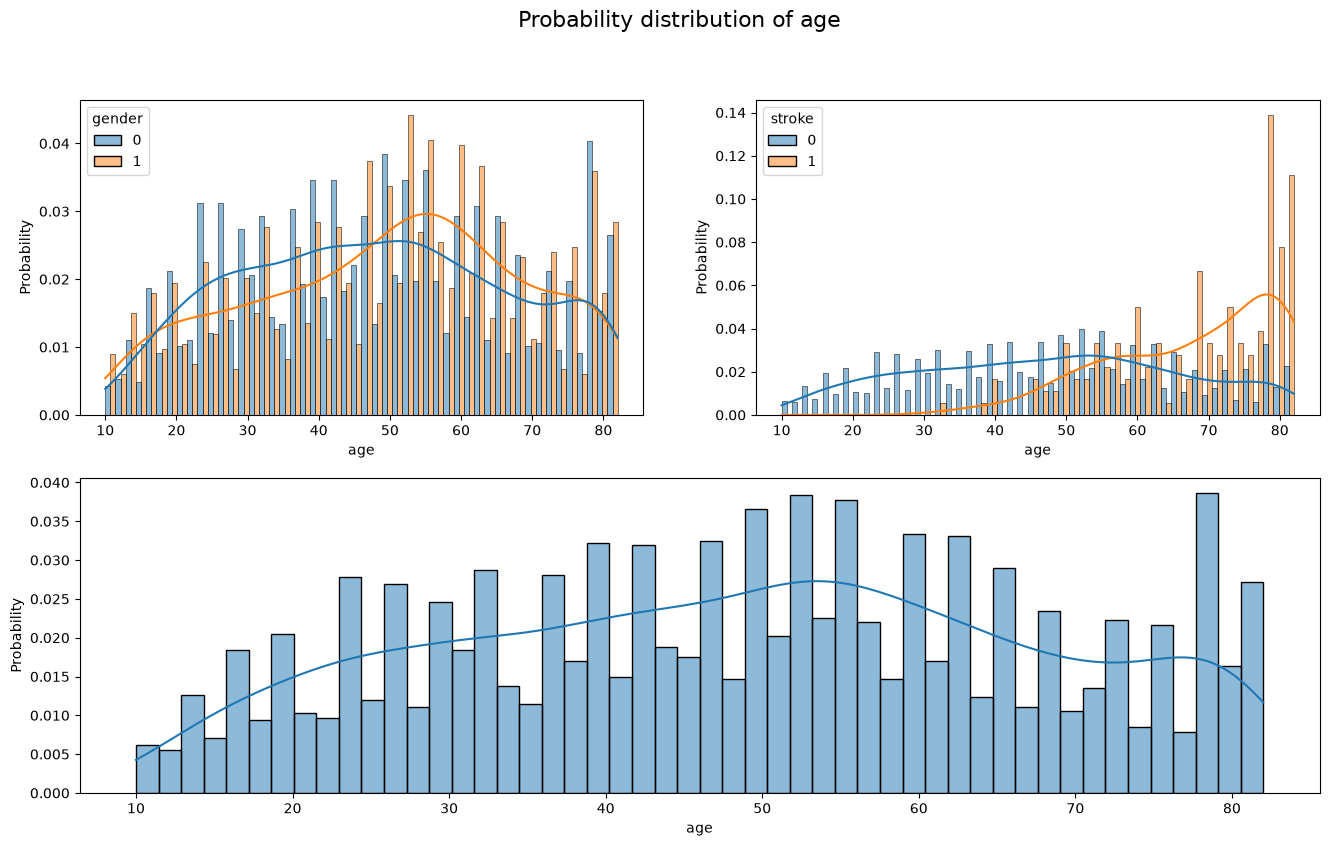

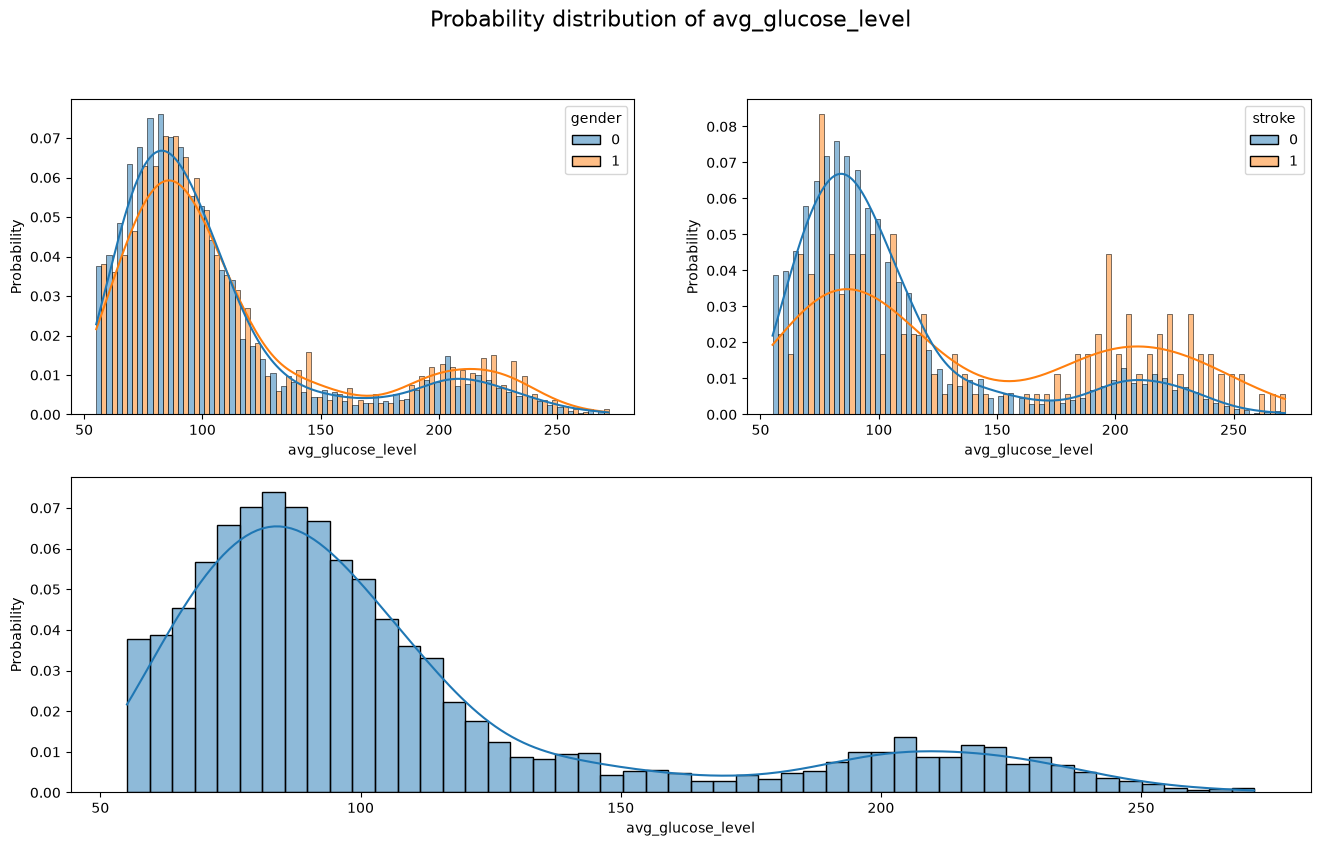

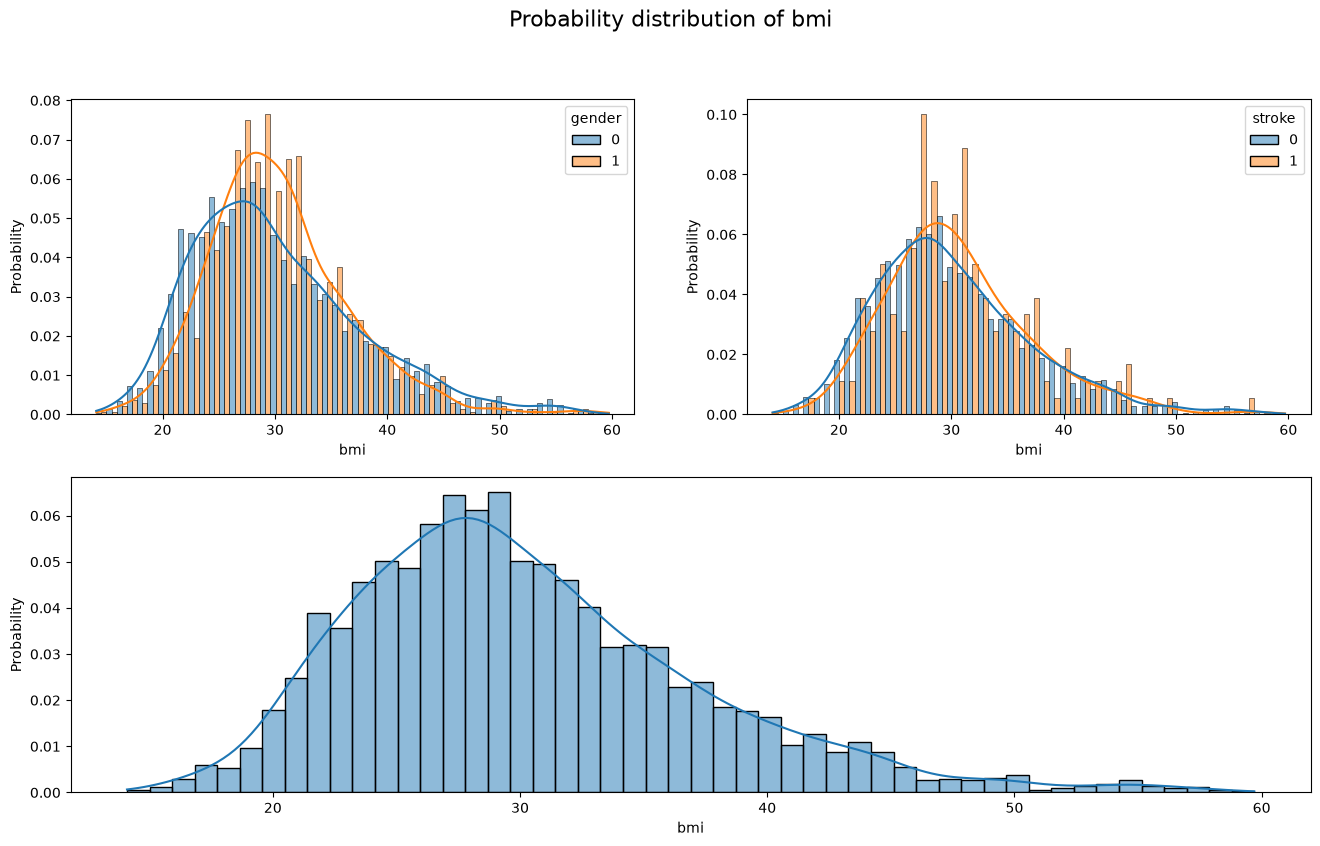

In [47]:
for feature in continuous_features:
  plot_cont_feature(
    stroke_data,
    feature,
    feature,
    class_label='stroke',
    hue_label='gender'
  )

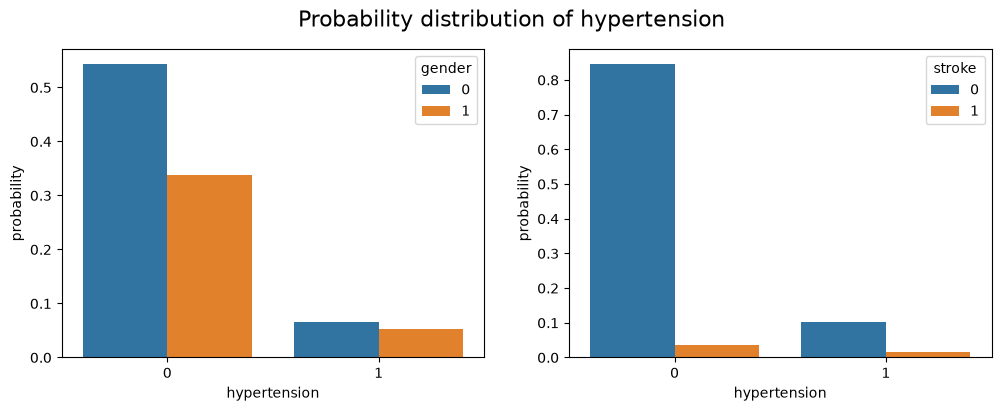

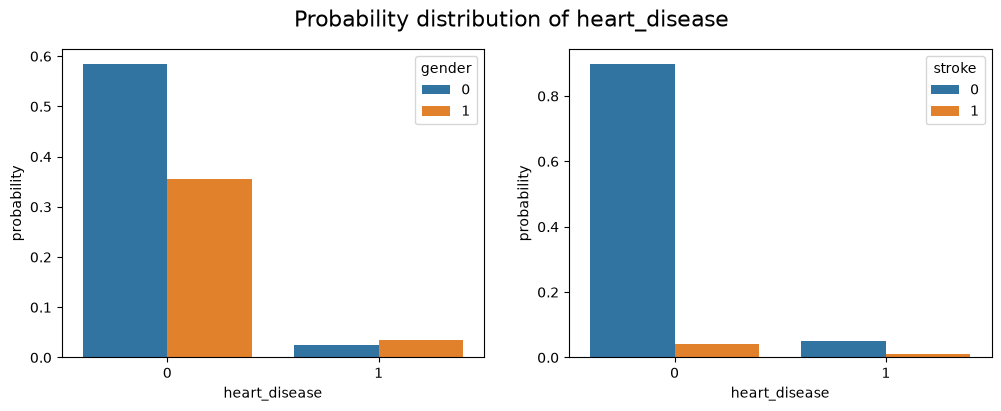

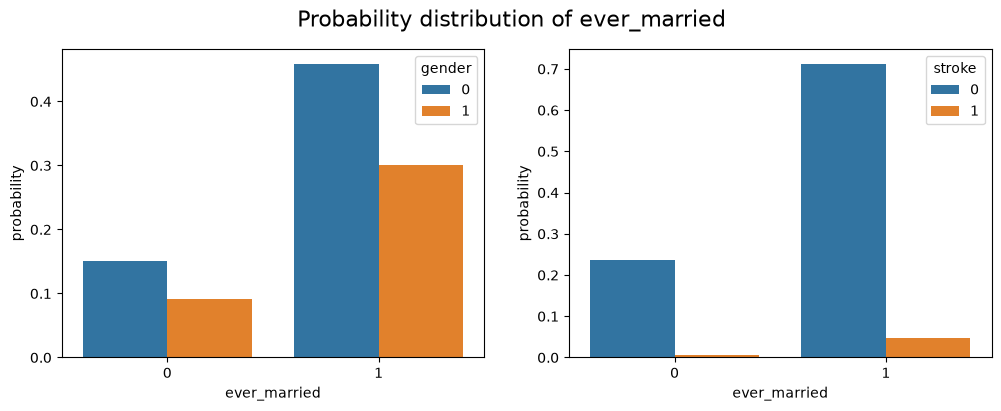

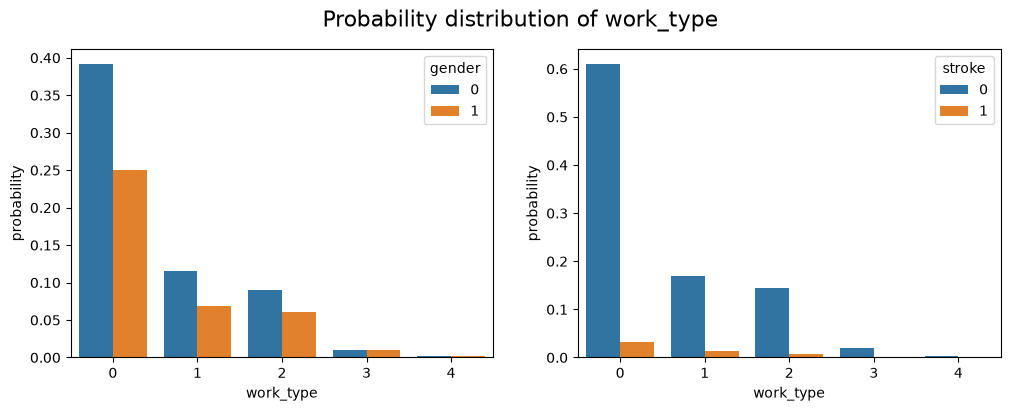

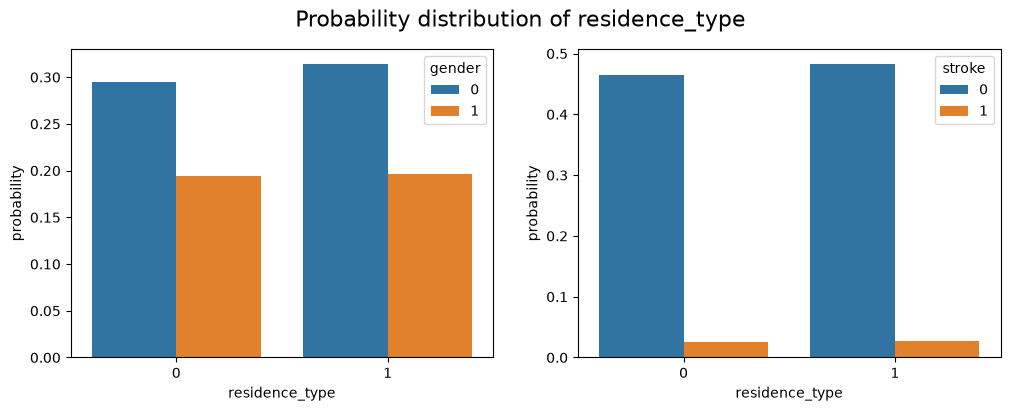

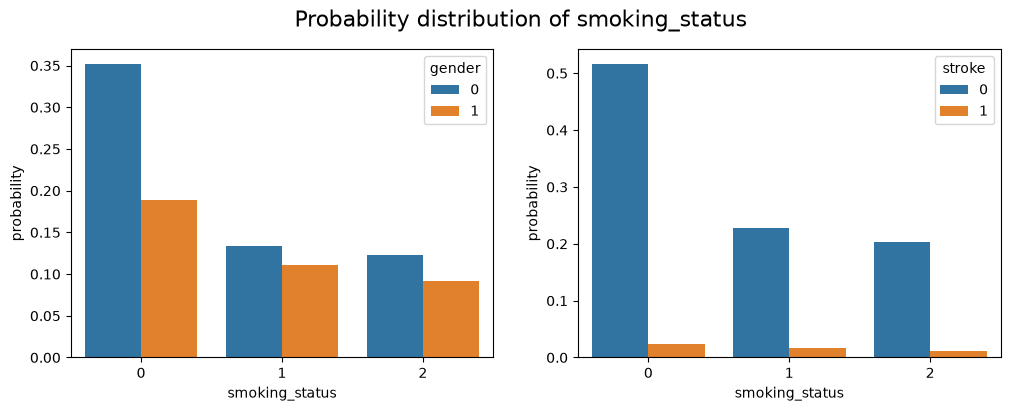

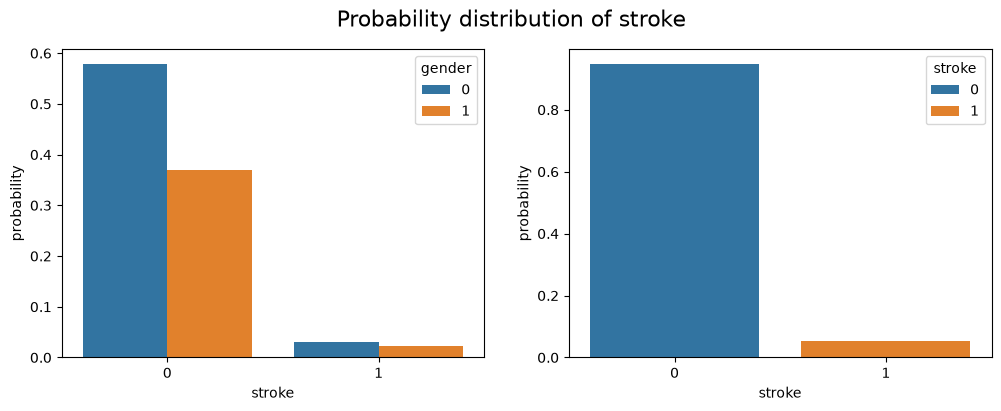

In [48]:
for feature in categorical_features:
  plot_cat_feature(
    stroke_data,
    feature,
    feature,
    class_label='stroke',
    hue_label='gender'
  )

# Train / Test split

In [49]:
from sklearn.model_selection import train_test_split

strata = stroke_data[['stroke', 'gender']]

train_df, test_df = train_test_split(
  stroke_data, 
  test_size=TEST_SIZE, 
  stratify=strata, 
  random_state=SEED
)

In [50]:
print(f"CEVAE-HE Training Set Size: {len(train_df)}")
print(f"CEVAE-HE Test and Classifier Bootstrap Set Size: {len(test_df)}")

print("\nTraining Set Gender Distribution by Target Outcome:")
print(pd.crosstab(train_df['gender'], train_df['stroke']))

print("\nTest Set Gender Distribution by Target Outcome:")
print(pd.crosstab(test_df['gender'], test_df['stroke']))

CEVAE-HE Training Set Size: 2732
CEVAE-HE Test and Classifier Bootstrap Set Size: 683

Training Set Gender Distribution by Target Outcome:
stroke     0   1
gender          
0       1580  84
1       1008  60

Test Set Gender Distribution by Target Outcome:
stroke    0   1
gender         
0       395  21
1       252  15


# Scaling

In [51]:
from processing_utils import StrataAwareRobustScaler

strata_scaler = StrataAwareRobustScaler(strata_col="gender", continuous_cols=continuous_features)
scaled_train_df = strata_scaler.fit_transform(train_df)
scaled_test_df = strata_scaler.transform(test_df)

# Save splits

In [52]:
scaled_train_df.to_csv(f"{PROJECT_ROOT}/{Config.DATA_DIR}/stroke/stroke_training.csv")
scaled_test_df.to_csv(f"{PROJECT_ROOT}/{Config.DATA_DIR}/stroke/stroke_test.csv")

## TRAINING table one

In [53]:
table1 = TableOne(scaled_train_df,
                  groupby='gender',
                  continuous=continuous_features,
                  categorical=categorical_features,
                  missing=False
                  )

print(table1)

                               Grouped by gender                          
                                         Overall            0            1
n                                           2732         1664         1068
age, mean (SD)                        -0.0 (0.7)    0.0 (0.6)   -0.1 (0.7)
hypertension, n (%)          0       2414 (88.4)  1487 (89.4)   927 (86.8)
                             1        318 (11.6)   177 (10.6)   141 (13.2)
heart_disease, n (%)         0       2568 (94.0)  1597 (96.0)   971 (90.9)
                             1         164 (6.0)     67 (4.0)     97 (9.1)
ever_married, n (%)          0        657 (24.0)   406 (24.4)   251 (23.5)
                             1       2075 (76.0)  1258 (75.6)   817 (76.5)
work_type, n (%)             0       1769 (64.8)  1081 (65.0)   688 (64.4)
                             1        497 (18.2)   309 (18.6)   188 (17.6)
                             2        404 (14.8)   241 (14.5)   163 (15.3)
                         

## TEST table one

In [54]:
table1 = TableOne(scaled_test_df,
                  groupby='gender',
                  continuous=continuous_features,
                  categorical=categorical_features,
                  missing=False
                  )

print(table1)

                               Grouped by gender                        
                                         Overall           0           1
n                                            683         416         267
age, mean (SD)                        -0.0 (0.7)   0.0 (0.6)  -0.1 (0.7)
hypertension, n (%)          0        597 (87.4)  368 (88.5)  229 (85.8)
                             1         86 (12.6)   48 (11.5)   38 (14.2)
heart_disease, n (%)         0        641 (93.9)  398 (95.7)  243 (91.0)
                             1          42 (6.1)    18 (4.3)    24 (9.0)
ever_married, n (%)          0        168 (24.6)  109 (26.2)   59 (22.1)
                             1        515 (75.4)  307 (73.8)  208 (77.9)
work_type, n (%)             0        422 (61.8)  256 (61.5)  166 (62.2)
                             1        131 (19.2)   83 (20.0)   48 (18.0)
                             2        110 (16.1)   67 (16.1)   43 (16.1)
                             3          17 (2.5)   

# Prototype classifier

## Outcome classifier

In [55]:
from src.cevaehe_new.causal_validation import run_downstream_probe

y_probe_results = run_downstream_probe(
  features = scaled_test_df.drop(columns=['stroke', 'gender']).values,
  target = scaled_test_df['stroke'].values,
  sens = scaled_test_df['gender'].values,
  dict_prefix="",
  cf_features=None,
  seed=SEED
)

In [56]:
y_probe_results_df = pd.DataFrame(y_probe_results, index=[0])

def format_score(score):
  return round(score*100, 2)

print("---- GLOBAL PERFORMANCE ----\n")
print(y_probe_results_df.filter(regex="global_.*").apply(format_score).to_markdown(index=False))
for g in [0, 1]:
  group_results = y_probe_results_df.filter(regex=f"{g}_.*")
  print(f"\n---- GROUP {g} PERFORMANCE ----\n")
  print(group_results.apply(format_score).to_markdown(index=False))

---- GLOBAL PERFORMANCE ----

|   global_mean_auprc |   global_std_auprc |   global_mean_recall |   global_std_recall |   global_mean_precision |   global_std_precision |
|--------------------:|-------------------:|---------------------:|--------------------:|------------------------:|-----------------------:|
|                20.6 |               4.43 |                   80 |               11.43 |                   13.73 |                   2.48 |

---- GROUP 0 PERFORMANCE ----

|   0_mean_auprc |   0_std_auprc |   0_mean_recall |   0_std_recall |   0_mean_precision |   0_std_precision |
|---------------:|--------------:|----------------:|---------------:|-------------------:|------------------:|
|           23.1 |          5.99 |           80.33 |          16.75 |              14.09 |              5.74 |

---- GROUP 1 PERFORMANCE ----

|   1_mean_auprc |   1_std_auprc |   1_mean_recall |   1_std_recall |   1_mean_precision |   1_std_precision |
|---------------:|--------------:|-----

## Gender classifier

In [57]:
from src.cevaehe_new.causal_validation import run_test_classifier

gender_classifier_results = run_test_classifier(
  features = scaled_test_df.drop(columns=['stroke', 'gender']).values,
  target = scaled_test_df['gender'].astype(int).values,
  scoring = "balanced_accuracy",
  seed=SEED
)

In [58]:
print(f"X -> Gender, balanced accuracy: {gender_classifier_results[0]:.4f} (std {gender_classifier_results[1]:.4f})")

X -> Gender, balanced accuracy: 0.6332 (std 0.0347)


# Mutual Info with S


--- Mutual Information with S ---

|                   |   count |       mean |       std |   min |       25% |         50% |        75% |       max |
|:------------------|--------:|-----------:|----------:|------:|----------:|------------:|-----------:|----------:|
| heart_disease     |     100 | 0.0410458  | 0.0404291 |     0 | 0.0127087 | 0.0301971   | 0.0571517  | 0.174277  |
| work_type         |     100 | 0.0304578  | 0.0353494 |     0 | 0         | 0.0177219   | 0.0498028  | 0.154898  |
| avg_glucose_level |     100 | 0.0223067  | 0.0268851 |     0 | 0         | 0.012971    | 0.0330109  | 0.122117  |
| age               |     100 | 0.0177073  | 0.0247834 |     0 | 0         | 7.15262e-05 | 0.0316608  | 0.10429   |
| hypertension      |     100 | 0.00724156 | 0.020252  |     0 | 0         | 0           | 0          | 0.147965  |
| ever_married      |     100 | 0.00762701 | 0.0197707 |     0 | 0         | 0           | 0          | 0.105713  |
| residence_type    |     100 | 0.00

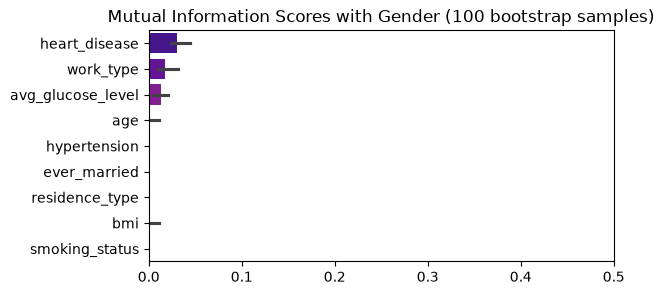

In [61]:
from analysis_utils import mutual_info_with_sens

mutual_info_with_sens(
  X=scaled_test_df.drop(columns=['stroke', 'gender']),
  Y=scaled_test_df['gender'].astype(int).values,
  target_label="Gender",
  n_samples=100,
  seed=SEED
)